In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [73]:
df = pd.read_csv("../data/spam.csv", encoding="latin-1")

In [74]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [75]:
df.shape

(5572, 5)

In [76]:
#1.Data Cleaning
#2.EDA
#3.Text preprocessing
#4.Model Building
#5.Evaluation
#6.Improvement
#7.Website
#8.deploy

### 1. Data Cleaning

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [78]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True)

In [79]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [80]:
#Renaming the columns
df.rename(columns={'v1' : 'label', 'v2' : 'sms'}, inplace=True)

In [81]:
from sklearn.preprocessing import LabelEncoder

In [82]:
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])

In [83]:
df.head()

,label,sms
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [84]:
#Missinf values
df.isnull().sum()

label    0
sms      0
dtype: int64

In [85]:
df.duplicated().sum()

np.int64(403)

In [86]:
#Drop duplicates
df = df.drop_duplicates(keep='first')
df = df.reset_index(drop=True)

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
df.shape

(5169, 2)

### 2. EDA

In [89]:
df.head()

,label,sms
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [90]:
df['label'].value_counts()

label
0    4516
1     653
Name: count, dtype: int64

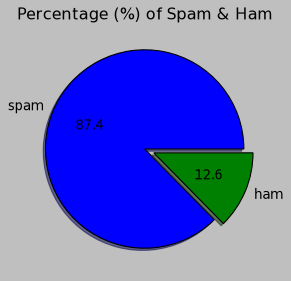

In [91]:
plt.style.use('classic')
plt.figure(figsize=(4,5))
plt.pie(df['label'].value_counts(),labels=['spam', 'ham'], autopct='%1.1f', explode=(0,0.1), shadow=True)
plt.title("Percentage (%) of Spam & Ham")
plt.show()

In [92]:
#Conclusion: Data is imbalanced

In [93]:
import nltk

In [94]:
df['num_characters'] = df['sms'].apply(len)

In [95]:
#num of words
df['num_words'] = df['sms'].apply(lambda x: len(nltk.word_tokenize(x)))

In [96]:
#num of sentences
df['num_sentences'] = df['sms'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [97]:
df.head()

,label,sms,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [98]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [99]:
#ham message
df[df['label'] == 0] [['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [100]:
#spam message
df[df['label'] == 1] [['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


Text(0.5, 1.0, 'Relation b/w every features')

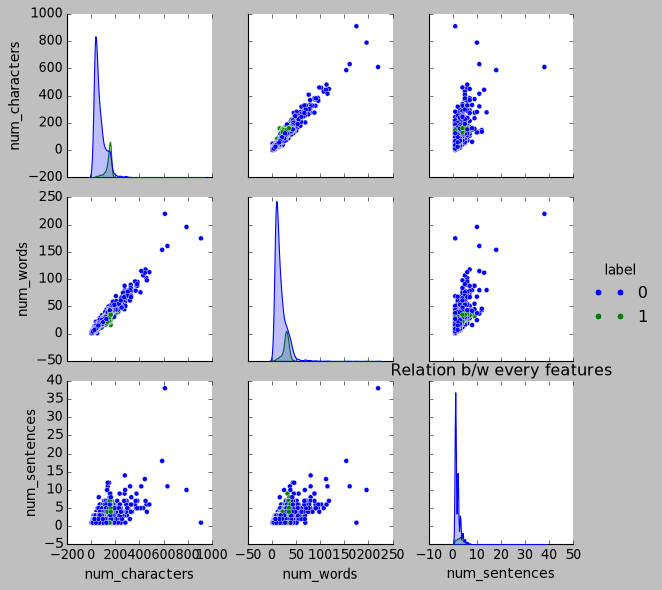

In [101]:
plt.Figure(figsize=(20, 20))
sns.pairplot(df, hue='label')
plt.title("Relation b/w every features")

In [102]:
df.head()

,label,sms,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [103]:
df.dtypes

label             int64
sms                 str
num_characters    int64
num_words         int64
num_sentences     int64
dtype: object

<Axes: >

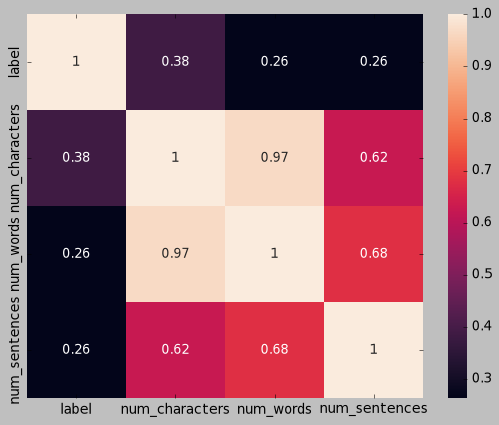

In [104]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### 3. Data Preprocessing
        1.Lowercase
        2.Tokenize
        3.Removing special characters
        4.Removing stopwards and special punctuations
        5.Stemming


In [105]:
import re
import nltk

In [106]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [107]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [108]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()


def transform_text(text):
    # Convert to string
    text = str(text)

    # 1. Lowercase
    text = text.lower()

    # 2. Remove HTML Tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # 3. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 4. Remove Email Addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # 5. Remove Numbers
    text = re.sub(r'\d+', ' ', text)

    # 6. Remove Special Characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 7. Remove Extra Whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 8. Tokenization
    tokens = word_tokenize(text)

    # 9. Remove Stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 10. Stemming
    tokens = [stemmer.stem(word) for word in tokens]

    # 11. Join Tokens
    return " ".join(tokens)

In [109]:
df['transformed_text'] = df['sms'].apply(transform_text)

In [110]:
df.head()

,label,sms,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [111]:
df['transformed_text'][0]

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

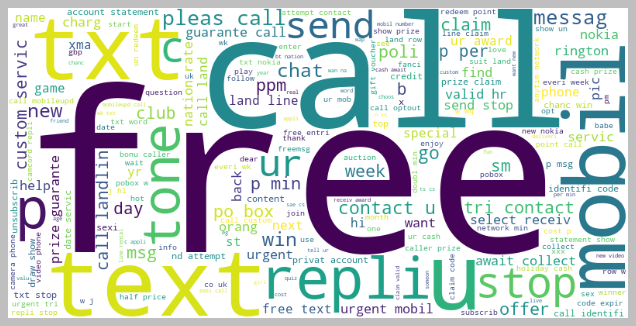

In [112]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color='white')

spam_wc = wc.generate(
    df[df['label'] == 1]['transformed_text'].str.cat(sep=" ")
)

plt.figure(figsize=(10,5))
plt.imshow(spam_wc)
plt.axis("off")
plt.show()

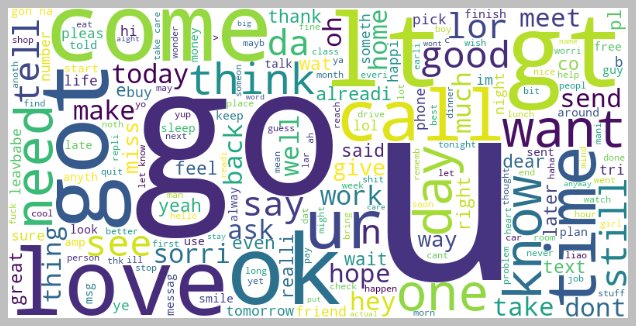

In [113]:
ham_wc = wc.generate(
    df[df['label'] == 0]['transformed_text'].str.cat(sep=" ")
)

plt.figure(figsize=(10,5))
plt.imshow(ham_wc)
plt.axis("off")
plt.show()

In [114]:
df.head()

,label,sms,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [115]:
spam_corpus = []
for msg in df[df['label'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [116]:
len(spam_corpus)

9667

In [117]:
from collections import Counter


In [118]:
Counter(spam_corpus).most_common(30)

[('call', 346),
 ('free', 197),
 ('u', 151),
 ('txt', 148),
 ('p', 148),
 ('text', 128),
 ('mobil', 121),
 ('ur', 119),
 ('stop', 114),
 ('repli', 104),
 ('claim', 98),
 ('prize', 84),
 ('min', 78),
 ('get', 75),
 ('tone', 73),
 ('cash', 65),
 ('servic', 65),
 ('new', 64),
 ('nokia', 62),
 ('send', 61),
 ('urgent', 58),
 ('award', 56),
 ('contact', 56),
 ('week', 55),
 ('c', 54),
 ('phone', 53),
 ('pleas', 52),
 ('msg', 52),
 ('win', 51),
 ('box', 49)]

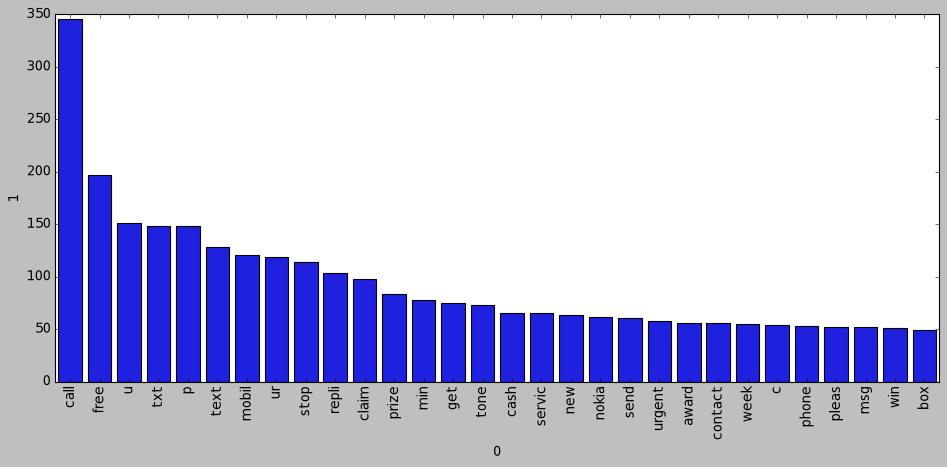

In [119]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],
    y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1]
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [122]:
ham_corpus = []
for msg in df[df['label'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [123]:
ham_corpus

['go',
 'jurong',
 'point',
 'crazi',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat',
 'ok',
 'lar',
 'joke',
 'wif',
 'u',
 'oni',
 'u',
 'dun',
 'say',
 'earli',
 'hor',
 'u',
 'c',
 'alreadi',
 'say',
 'nah',
 'think',
 'goe',
 'usf',
 'live',
 'around',
 'though',
 'even',
 'brother',
 'like',
 'speak',
 'treat',
 'like',
 'aid',
 'patent',
 'per',
 'request',
 'mell',
 'mell',
 'oru',
 'minnaminungint',
 'nurungu',
 'vettam',
 'set',
 'callertun',
 'caller',
 'press',
 'copi',
 'friend',
 'callertun',
 'gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today',
 'search',
 'right',
 'word',
 'thank',
 'breather',
 'promis',
 'wont',
 'take',
 'help',
 'grant',
 'fulfil',
 'promis',
 'wonder',
 'bless',
 'time',
 'date',
 'sunday',
 'oh',
 'k',
 'watch',
 'eh',
 'u',
 'rememb',
 'spell',
 'name',
 'ye',
 'v',
 'naughti',
 'make',
 'v',
 'wet',
 'fine',
 'way',
 'u',
 'fe

In [124]:
len(ham_corpus)

35472

In [125]:
Counter(ham_corpus).most_common(30)

[('u', 922),
 ('go', 409),
 ('get', 358),
 ('gt', 288),
 ('lt', 287),
 ('come', 277),
 ('ok', 255),
 ('call', 240),
 ('got', 239),
 ('like', 236),
 ('know', 236),
 ('time', 225),
 ('love', 225),
 ('day', 218),
 ('good', 216),
 ('want', 210),
 ('ur', 198),
 ('need', 174),
 ('one', 165),
 ('lor', 159),
 ('home', 156),
 ('think', 150),
 ('take', 148),
 ('see', 147),
 ('still', 145),
 ('da', 143),
 ('k', 138),
 ('tell', 135),
 ('make', 130),
 ('today', 129)]

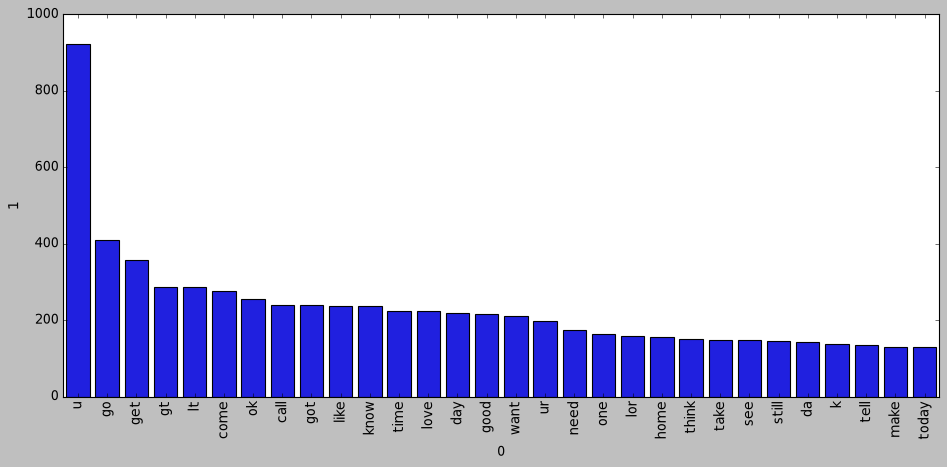

In [126]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],
    y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1]
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [127]:
df.head()

,label,sms,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [129]:
df.to_csv("../data/processed_spam.csv", index=False)

In [131]:
df.isnull().sum()

label               0
sms                 0
num_characters      0
num_words           0
num_sentences       0
transformed_text    0
dtype: int64